# **Data Preprocessing**




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler

In [2]:
# Define column names based on dataset documentation
columns = ['unit_id', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']
columns += [f'sensor_{i}' for i in range(1, 22)]

# Load data from text file
train_df = pd.read_csv('data/train_FD001.txt', sep=' ', header=None, names=columns, index_col=False)

C:\Users\Amey\AppData\Local\Temp\ipykernel_18760\2853012074.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv('data/train_FD001.txt', sep=' ', header=None, names=columns, index_col=False)


In [3]:
print(train_df.nunique())

unit_id         100
time_cycles     362
setting_1       158
setting_2        13
setting_3         1
sensor_1          1
sensor_2        310
sensor_3       3012
sensor_4       4051
sensor_5          1
sensor_6          2
sensor_7        513
sensor_8         53
sensor_9       6403
sensor_10         1
sensor_11       159
sensor_12       427
sensor_13        56
sensor_14      6078
sensor_15      1918
sensor_16         1
sensor_17        13
sensor_18         1
sensor_19         1
sensor_20       120
sensor_21      4745
dtype: int64


In [4]:
train_df.shape

(20631, 26)

In [5]:
train_df.head()

,unit_id,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
engine_1 = train_df[train_df['unit_id'] == 1]
print(f"\nEngine 1 lifecycle: {engine_1['time_cycles'].max()} cycles before failure")


Engine 1 lifecycle: 192 cycles before failure


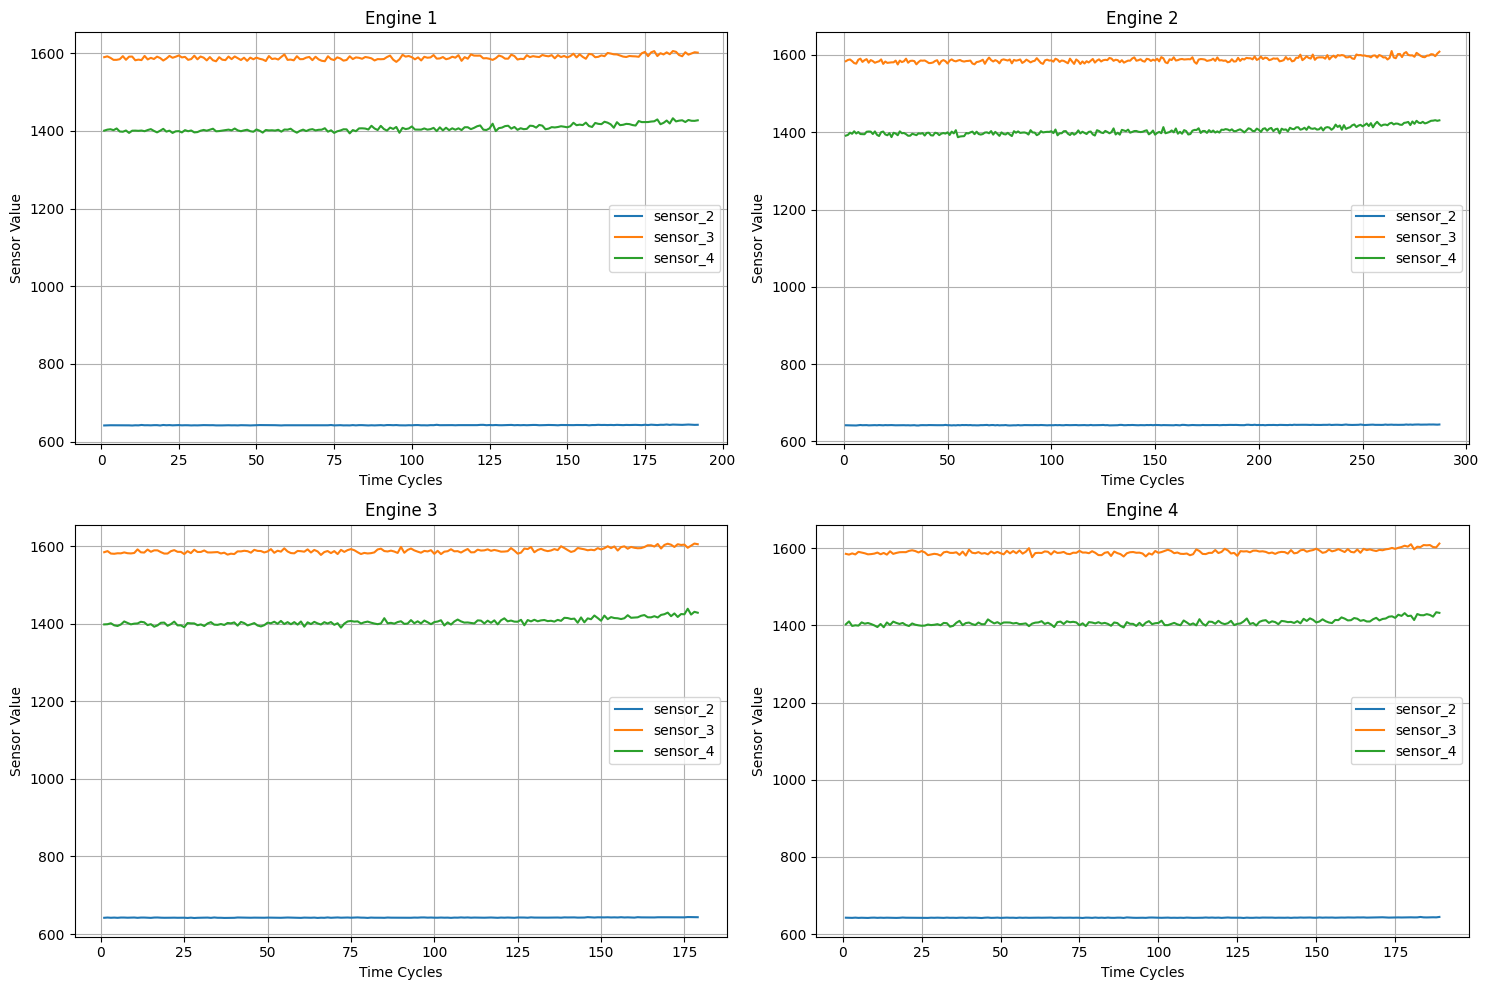

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, engine_id in enumerate([1, 2, 3, 4]):

    ax = axes[i // 2, i % 2]
    engine_data = train_df[train_df['unit_id'] == engine_id]

    for sensor in ['sensor_2', 'sensor_3', 'sensor_4']:
        ax.plot(engine_data['time_cycles'],
                engine_data[sensor],
                label=sensor)

    ax.set_title(f'Engine {engine_id}')
    ax.set_xlabel('Time Cycles')
    ax.set_ylabel('Sensor Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [8]:
print(f"Engines: {train_df['unit_id'].nunique()}")

Engines: 100


In [9]:
# Compute Remaining Useful Life (RUL)

# Find the final operational cycle for every engine
max_cycles = train_df.groupby("unit_id")["time_cycles"].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']


# Attach failure cycle info back to original dataframe
train_df = train_df.merge(max_cycles, on='unit_id', how='left')

# RUL calculation
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']

print("RUL feature added successfully")
print(f"Minimum RUL: {train_df['RUL'].min()}")
print(f"Maximum RUL: {train_df['RUL'].max()}")

print("\nSample records from Engine 1:")
display(
    train_df.loc[
        train_df["unit_id"] == 1,
        ["unit_id", "time_cycles", "max_cycle", "RUL"]
    ].head(10)
)

RUL feature added successfully
Minimum RUL: 0
Maximum RUL: 361

Sample records from Engine 1:


,unit_id,time_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [10]:
# Create sensor column list
sensor_features = [f"sensor_{i}" for i in range(1, 22)]

# Calculate variance of every sensor
variance_values = train_df[sensor_features].var()

# Sort variances
variance_values = variance_values.sort_values()

print("Sensor variances:\n")

for sensor_name, variance in variance_values.items():
    print(f"{sensor_name:<12} --> {variance:.6f}")

Sensor variances:

sensor_1     --> 0.000000
sensor_10    --> 0.000000
sensor_19    --> 0.000000
sensor_18    --> 0.000000
sensor_16    --> 0.000000
sensor_5     --> 0.000000
sensor_6     --> 0.000002
sensor_15    --> 0.001407
sensor_8     --> 0.005039
sensor_13    --> 0.005172
sensor_21    --> 0.011718
sensor_20    --> 0.032669
sensor_11    --> 0.071336
sensor_2     --> 0.250053
sensor_12    --> 0.543985
sensor_7     --> 0.783388
sensor_17    --> 2.398667
sensor_3     --> 37.590994
sensor_4     --> 81.010886
sensor_14    --> 363.900490
sensor_9     --> 487.653568


In [11]:
# Removing low variance sensors

# Define cutoff threshold
variance_cutoff = 0.001

# Identify weak sensors
discarded_sensors = (variance_values[variance_values < variance_cutoff].index.tolist())

print(f"Sensors to remove ({len(discarded_sensors)}):")
print(discarded_sensors)

# Drop useless sensors
train_df.drop(columns=discarded_sensors, inplace=True)

# Keep only useful sensors
sensor_features = [s for s in sensor_features if s not in discarded_sensors]

print(f"\nRemaining sensors: {len(sensor_features)}")
print(sensor_features)

Sensors to remove (7):
['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5', 'sensor_6']

Remaining sensors: 14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [12]:
# Correlation analysis with RUL

# Compute correlations
rul_corr = (train_df[sensor_features + ["RUL"]].corr()["RUL"].drop("RUL").sort_values())

print("Correlation values:\n")

for feature, corr_value in rul_corr.items():
    print(f"{feature:<12} --> {corr_value:.4f}")

Correlation values:

sensor_11    --> -0.6962
sensor_4     --> -0.6789
sensor_15    --> -0.6427
sensor_2     --> -0.6065
sensor_17    --> -0.6062
sensor_3     --> -0.5845
sensor_8     --> -0.5640
sensor_13    --> -0.5626
sensor_9     --> -0.3901
sensor_14    --> -0.3068
sensor_20    --> 0.6294
sensor_21    --> 0.6357
sensor_7     --> 0.6572
sensor_12    --> 0.6720


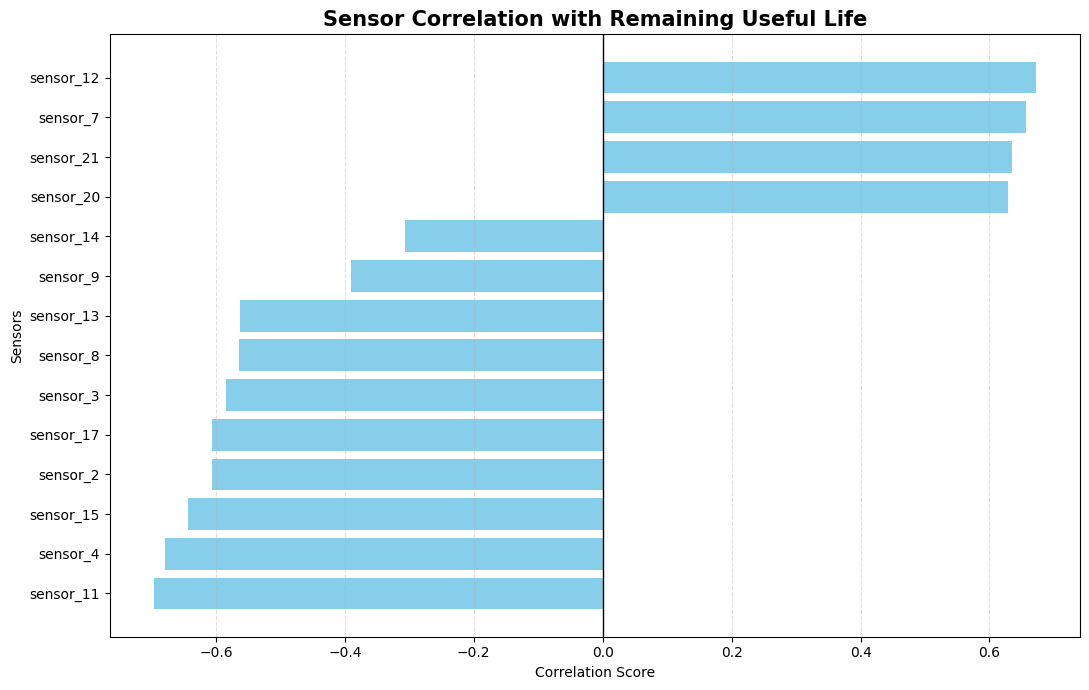

In [13]:
#Visualize correlations

plt.figure(figsize=(11, 7))
bars = plt.barh(rul_corr.index, rul_corr.values, color="skyblue")
plt.title("Sensor Correlation with Remaining Useful Life", fontsize=15, fontweight="bold")
plt.xlabel("Correlation Score")
plt.ylabel("Sensors")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.axvline( x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [14]:
#  Normalize features

# Operating settings + selected sensors
model_features = (["setting_1", "setting_2", "setting_3"] + sensor_features)

print(f"Total features selected: {len(model_features)}")

# Initialize scaler
normalizer = MinMaxScaler()

# Apply normalization
train_df[model_features] = normalizer.fit_transform(train_df[model_features])

Total features selected: 17


In [15]:
#  Verify normalized feature ranges

display(train_df[model_features].describe().loc[["min", "max"]])

,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [16]:
# Summary

print(f"\nTotal rows processed      : {len(train_df):,}")
print(f"Total engines             : {train_df['unit_id'].nunique()}")
print(f"Final feature count       : {len(model_features)}")
print(f"Removed low-var sensors   : {len(discarded_sensors)}")
print(f"Useful sensors retained   : {len(sensor_features)}")


Total rows processed      : 20,631
Total engines             : 100
Final feature count       : 17
Removed low-var sensors   : 7
Useful sensors retained   : 14


In [17]:
# Save processed dataset
train_df.to_csv("data/train_processed.csv", index=False)

In [18]:
joblib.dump(model_features, 'data/feature_columns.pkl')

['data/feature_columns.pkl']